# Task 3: Evaluate Deforestation through Bitemporal Change Detection

In this final task we quantify deforestation in São Félix do Xingu based on bitemporal satellite observations. We use the Sentinel-2 tile T22MCU previously downloaded and visualized in Task 1, and the CNN-based segmentation model from Task 2 for comparison. Our objective is to measure both absolute and relative forest loss between 2018 and 2024. In this task we perform quantitative change detection at the patch level using two complementary approaches:

- **NDVI differencing**
- **CNN segmentation differencing**

The combined evaluation enables us to assess the agreement between physical indices and data-driven model outputs while identifying specific strengths and limitations of both approaches. 

We focus on tile **T22MCU** which covers one of the most deforested sectors in the municipality and shows strong spatial variability in canopy loss. 

**Important Note**

If you were not able to complete Task 1 or 2, we provide a preprocessed version of the tile and a simple pretrained CNN model for this task. Please use these resources if necessary.
The model can be loaded with `model = torch.jit.load("backup_model.pt")`




### Imports
These are all imports we used when solving the task. Please leave them as is even though you might not need all of them.

In [1]:
import os
import rootutils
root = rootutils.setup_root(os.path.abspath(''), dotenv=True, pythonpath=True, cwd=False)

data_path = root / "data"
data_path.mkdir(exist_ok=True)
output_dir = root / "output"
output_dir.mkdir(exist_ok=True)
root

PosixPath('/mnt/c/Users/binhp/Desktop/Studium/Master/Semester 01/IPL4EO/ipl4eo-dependencies/ipl4eo_miniproject_2025')

In [2]:
from abc import ABC, abstractmethod
from pathlib import Path
from typing import Dict, Tuple, Optional
from dataclasses import dataclass, field
import numpy as np
import torchvision.transforms as transforms
from matplotlib import pyplot as plt
from tqdm import tqdm
import torch
import sys


## 3.1 Patch Extraction and Preprocessing

- Load the tile
  
- Perform bilinear interpolation of 20m bands to 10m spatial resolution for all 20m bands of the tile (You could use [Rasterio](https://rasterio.readthedocs.io/en/stable/topics/resampling.html))

- Divide the tile into non-overlapping patches of size **120 x 120 pixels**.


In [3]:
# Your code goes here
import rasterio
from rasterio.enums import Resampling
import geopandas as gpd

# code taken from Lab01
def read_s2_jp2_data_with_clipping(band_data_path: Path, clip_geoseries: gpd.GeoSeries, envelope: bool = True) -> np.ndarray:
    """
    Given the `band_data_path` to a JP2000 encoded GeoTIFF file, return those parts that are overlapping with the
    `clip_geoseries` GeoSeries. By default, the bounding box (`envelope`) of the geometry will be used to define the
    region of interest.
    """
    # open the GeoTIFF file which also contains the CRS metadata
    with rasterio.open(band_data_path) as data:
        # ensure that the data is using the same coordinate reference system and reproject if they don't
        reprojected_geoseries = clip_geoseries.to_crs(data.crs)
        # use the bounding box if `envelope` is set => Make sure that the matrix we get back can contain
        # only valid values
        reprojected_geoseries = (
            reprojected_geoseries.envelope if envelope else reprojected_geoseries
        )
        # Use crop to only return the matrix that contains our region of interest
        # Use `all_touched=True` to make sure that the border is also conisdered "inside" the region of interest
        out_img, _out_transform = rasterio.mask.mask(
            data, reprojected_geoseries, crop=True, all_touched=True
        )
        # drop singleton axes
        out_img = out_img.squeeze()
    return out_img

class S2TileReader:
    def __init__(self, directory: Path):
        """
        Initialize the reader with a directory containing the SAFE file of a Sentinel-2 product.

        Parameters
        ----------
        directory : Path
            The directory containing the SAFE file of a Sentinel-2 product.
        """
        assert directory.is_dir(), f"{directory} is not a directory"
        self.image_files = list(directory.glob(f"**/IMG_DATA/*.jp2"))
        if len(self.image_files) == 0:
            self.image_files = list(directory.glob(f"**/IMG_DATA/R60m/*.jp2"))
            self.image_files.extend(list(directory.glob(f"**/IMG_DATA/R20m/*.jp2")))
            self.image_files.extend(list(directory.glob(f"**/IMG_DATA/R10m/*.jp2")))
        self.band2file_mapping = self._bands()
        self.bands = sorted(self.band2file_mapping.keys())
        print(f"{len(self.band2file_mapping)} images found in {directory}")

    def _bands(self):
        """
        Extract the band names from the image files and create a mapping from band name to file path.

        Example:
        {
            "B01": Path("path/to/B01.jp2"),
            "B02": Path("path/to/B02.jp2"),
            ...
        }
        or if the product has multiple resolutions:
        {
            "B01_60m": Path("path/to/R60m/B01.jp2"),
            "B02_10m": Path("path/to/R10m/B02.jp2"),
            ...
        }
        """
        return {"_".join(x.stem.split("_")[2:]):x for x in self.image_files}

    def read_band(self, band: str):
        """
        Read the data of a specific band. The data is returned as a numpy array. If the band is a single channel,
        the array will have shape (height, width). If the band is a multi-channel band, the array will have shape
        (height, width, channels).

        Parameters
        ----------
        band : str
            The name of the band to read. Must be one of the bands in the product.
            Use the `bands` attribute to see the available bands.
        """
        assert band in self.bands, f"Band {band} invalid. Please select one of {self.bands}"
        img_path = self.band2file_mapping[band]

        # Bilinear interpolation of 20m bands to 10m spatial resolution
        upscale_factor = 2
        
        with rasterio.open(self.band2file_mapping[band]) as f:
            # Upsample from 20m to 10m
            if "20m" in band:
                data = f.read(
                    out_shape=(
                        f.count,
                        int(f.height * upscale_factor),
                        int(f.width * upscale_factor)
                    ),
                    resampling=Resampling.bilinear
                )
                # scale image transform
                transform = f.transform * f.transform.scale(
                    (f.width / data.shape[-1]),
                    (f.height / data.shape[-2])
                )
            else:
                data = f.read()
            
        if data.shape[0] == 1:
            return data.squeeze(0)
        elif data.shape[0] == 3:
            return np.transpose(data, (1, 2, 0))

    def read_band_data_with_clipping(
        self, band: str, clip_geoseries: gpd.GeoSeries, envelope: bool = True
    ) -> np.ndarray:
        assert band in self.bands, f"Band {band} invalid. Please select one of {self.bands}"
        img_path = self.band2file_mapping[band]
        return read_s2_jp2_data_with_clipping(img_path, clip_geoseries, envelope=envelope)


DESIRED_BANDS =['B02_10m', 'B03_10m', 'B04_10m', 'B08_10m',
               'B05_20m', 'B06_20m', 'B07_20m', 'B8A_20m',
               'B11_20m', 'B12_20m']


In [4]:
# Load tile from 2018
dir_2018 = Path("./Sentinel-2/MSI/L2A_N0500/2018/07/23/S2B_MSIL2A_20180723T135109_N0500_R024_T22MCU_20230628T084231.SAFE")
s2_reader = S2TileReader(dir_2018)
s2_reader.bands
image_2018 = np.stack([s2_reader.read_band(b) for b in DESIRED_BANDS], axis=-1)

# Devide into patches
division = int(np.floor(len(image_2018[0]) / 120))
image_2018_cropped = image_2018[:120 * division, :120 * division, :]

# Drop numpy array to save memory. Otherwise, kernel will die
del image_2018

patches_2018 = image_2018_cropped.reshape( division, 120, division, 120, 10)
patches_2018 = patches_2018.transpose(0, 2, 1, 3, 4)
patches_2018 = patches_2018.reshape(-1, 120, 120, 10)

del image_2018_cropped
patches_2018.shape

10 images found in Sentinel-2/MSI/L2A_N0500/2018/07/23/S2B_MSIL2A_20180723T135109_N0500_R024_T22MCU_20230628T084231.SAFE


(8281, 120, 120, 10)

In [5]:
# Load tile from 2024
dir_2024 = Path("./Sentinel-2/MSI/L2A/2024/07/21/S2B_MSIL2A_20240721T134709_N0510_R024_T22MCU_20240721T160820.SAFE")
s2_reader = S2TileReader(dir_2024)
s2_reader.bands
image_2024 = np.stack([s2_reader.read_band(b) for b in DESIRED_BANDS], axis=-1)

# Devide into patches
image_2024_cropped = image_2024[:120 * division, :120 * division, :]

del image_2024

patches_2024 = image_2024_cropped.reshape( division, 120, division, 120, 10)
patches_2024 = patches_2024.transpose(0, 2, 1, 3, 4)
patches_2024 = patches_2024.reshape(-1, 120, 120, 10)

del image_2024_cropped

10 images found in Sentinel-2/MSI/L2A/2024/07/21/S2B_MSIL2A_20240721T134709_N0510_R024_T22MCU_20240721T160820.SAFE


## 3.2 Change detection
### 3.2.1 NDVI and CNN Mask Calculation

For each extracted patch compute:

 a. NDVI
 
 b. CNN Mask
    - Apply the CNN segmentation model from Task 2 to each patch. (**Note:** don't forget to preprocess)
    
To convert it into a binary mask, find a good threshhold. Argue your choice for the NDVI and CNN in a short paragraph.

### 3.2.2 Change Detection and Forest Loss Computation

For both NDVI and CNN masks compute for the full tile (all patches):

- **Percentage loss:**  
  percentage_loss = 100 * (forest_pixels_2018 - forest_pixels_2024) / forest_pixels_2018

- **Absolute loss (m²):**  
  absolute_loss = (forest_pixels_2018 - forest_pixels_2024) * 100

where `forest_pixels_2018` and `forest_pixels_2024` are the number of forest pixels in 2018 and 2024, respectively. Each pixel represents 100 m² (10m resolution).


In [6]:
# NDVI
def count_forest_pixels(masks):
    count = 0
    for m in masks:
        count_patch = np.count_nonzero(m)
        count += count_patch
    return count

ndvi_masks_2018 = []
ndvi_masks_2024 = []
threshold = 0.5

# Compute NDVI masks for all patches from 2018 and 2024
# Pixel is classified as 1 (forest) if NDVI value >= threshold. Otherwise, 0 (non-forest)
for p in patches_2018:
    red = p[:, :, 2].astype(np.float32)
    nir = p[:, :, 3].astype(np.float32)
    ndvi = (nir - red) / (nir + red + 1e-6)
    mask = (ndvi >= threshold) * 1
    ndvi_masks_2018.append(mask)
    
for p in patches_2024:
    red = p[:, :, 2].astype(np.float32)
    nir = p[:, :, 3].astype(np.float32)
    ndvi = (nir - red) / (nir + red + 1e-6)
    mask = (ndvi >= threshold) * 1
    ndvi_masks_2024.append(mask)

# Forest loss computation
forest_pixels_2018 = count_forest_pixels(ndvi_masks_2018)
forest_pixels_2024 = count_forest_pixels(ndvi_masks_2024)
percentage_loss = 100 * (forest_pixels_2018 - forest_pixels_2024) / (forest_pixels_2018 + 1e-6)
absolute_loss = (forest_pixels_2018 - forest_pixels_2024) * 100

print(f"forest_pixels_2018: {forest_pixels_2018}")
print(f"forest_pixels_2024: {forest_pixels_2024}")
print(f"percentage_loss: {percentage_loss:.2f}%")
print(f"absolute_loss: {absolute_loss:.2f}m^2")

forest_pixels_2018: 73590794
forest_pixels_2024: 68226945
percentage_loss: 7.29%
absolute_loss: 536384900.00m^2


In [7]:
# Save 6 representative patches for Task 3.3
indices = [5277, 7384, 8240, 8271, 8230, 965]
representatives_ndvi_2018 = [ndvi_masks_2018[i] for i in indices]
del ndvi_masks_2018
representatives_ndvi_2024 = [ndvi_masks_2024[i] for i in indices]
del ndvi_masks_2024

In [8]:
# CNN
mean =  np.array([438.37207031, 614.05566406, 588.40960693, 2193.29199219, 942.84332275, 1769.93164062, 2049.55151367, 1568.22680664, 997.73248291, 2235.55664062])
std = np.array([607.02685547, 603.29681396, 684.56884766, 1369.3717041, 738.43267822, 1100.45605469, 1275.80541992, 1070.16125488, 813.52764893, 1356.54406738])

model = torch.jit.load("../../data/backup_model.pt")
model.eval()

cnn_masks_2018 = []
cnn_masks_2024 = []
threshold = 0.3

# CNN generates mask for each patch from 2018 and 2024
for p in patches_2018:
    # Normalization using mean and std from Task 2
    p_norm = ((p - mean[None, None, :]) / std[None, None, :]).astype(np.float32)
    # Make batch compatible with the model ((height, width, bands) --> (1, bands, height, width))
    p_batch = torch.from_numpy(p_norm).permute(2, 0, 1).unsqueeze(0)
    # Get model predictions by applying softmax to logits
    with torch.no_grad():
        logits = model(p_batch)
    probs = torch.softmax(logits, dim=1)
    # Pixel is classified as 1 (forest) if probability of being forest >= threshold. Otherwise, 0 (non-forest)
    forest_probs = probs[0, 1, :, :]
    pred_mask = (forest_probs >= threshold).numpy().astype(np.uint8)
    cnn_masks_2018.append(pred_mask)

for p in patches_2024:
    p_norm = ((p - mean[None, None, :]) / std[None, None, :]).astype(np.float32)
    p_batch = torch.from_numpy(p_norm).permute(2, 0, 1).unsqueeze(0)
    with torch.no_grad():
        logits = model(p_batch)
    probs = torch.softmax(logits, dim=1)
    forest_probs = probs[0, 1, :, :]
    pred_mask = (forest_probs >= threshold).numpy().astype(np.uint8)
    cnn_masks_2024.append(pred_mask)

# Forest loss computation
forest_pixels_2018 = count_forest_pixels(cnn_masks_2018)
forest_pixels_2024 = count_forest_pixels(cnn_masks_2024)
percentage_loss = 100 * (forest_pixels_2018 - forest_pixels_2024) / (forest_pixels_2018 + 1e-6)
absolute_loss = (forest_pixels_2018 - forest_pixels_2024) * 100

print(f"forest_pixels_2018: {forest_pixels_2018}")
print(f"forest_pixels_2024: {forest_pixels_2024}")
print(f"percentage_loss: {percentage_loss:.2f}%")
print(f"absolute_loss: {absolute_loss:.2f}m^2")

forest_pixels_2018: 77870154
forest_pixels_2024: 76470813
percentage_loss: 1.80%
absolute_loss: 139934100.00m^2


In [9]:
# Save representative patches for Task 3.3 and delete arrays to save memory
representatives_cnn_2018 = [cnn_masks_2018[i] for i in indices]
del cnn_masks_2018
representatives_cnn_2024 = [cnn_masks_2024[i] for i in indices]
del cnn_masks_2024
representatives_patches_2018 = [patches_2018[i] for i in indices]
representatives_patches_2024 = [patches_2024[i] for i in indices]
del patches_2018
del patches_2024

**TODO:** Describe the results in a few paragraphs.

We divided the images into 8281 patches respectively. Then, we applied the NDVI and CNN method to all patches from 2018 and 2024. As CNN, we used the given backup model. To save memory, we deleted unused numpy arrays. Otherwise, the kernel would die due to the limited RAM.

For the NDVI masks, we used 0.5 as a threshold. 0.6 was too high since most pixels that seemed to be forest were labeled as non-forest. Conversely, 0.4 was too low because a lot of pixels with little vegetation, such as meadows and grain fields, were incorrectly classified as non-forest. Hence, we chose 0.5. However, we must note that using 0.4 resulted in predictions with less noise compared to those generated with 0.5. However, the noise is not that pronounced in most patches, so the broad shapes of forest and non-forest areas are mostly still recognizable.

For the CNN masks, we used 0.3 as a threshold. 0.4 was too high as the CNN classified most pixels as non-forest. Thresholds lower than 0.3 generally resulted in more random predictions.

NDVI estimates a percentage loss of 7.29% and an absolute loss of 536384900m². Using the CNN, the percentage loss is about 1.80% and the absolute loss 139934100m².

## 3.3 Extensive Qualitative Analysis

Select six representative patches:

- Two patches with high loss.
- Two patches with minimal or no loss.
- Two patches with interesting discrepancies between methods.

For each patch plot:

- RGB composite for 2018 and 2024.
- CNN mask for 2018 and 2024.
- NDVI mask for 2018 and 2024.

Annotate each visualization with the computed percentage loss for both NDVI and CNN.



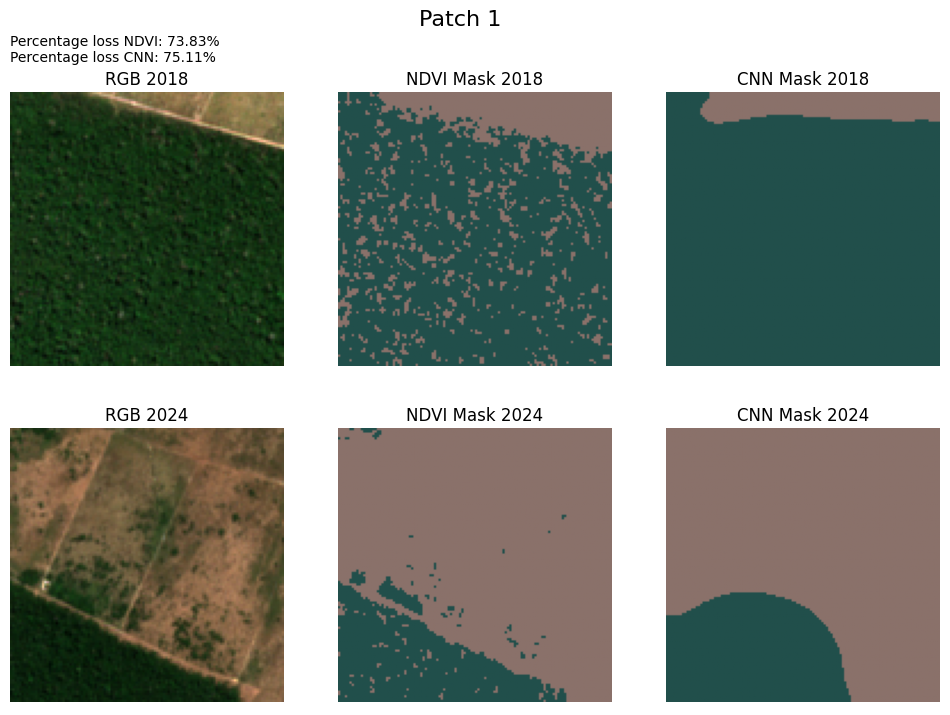

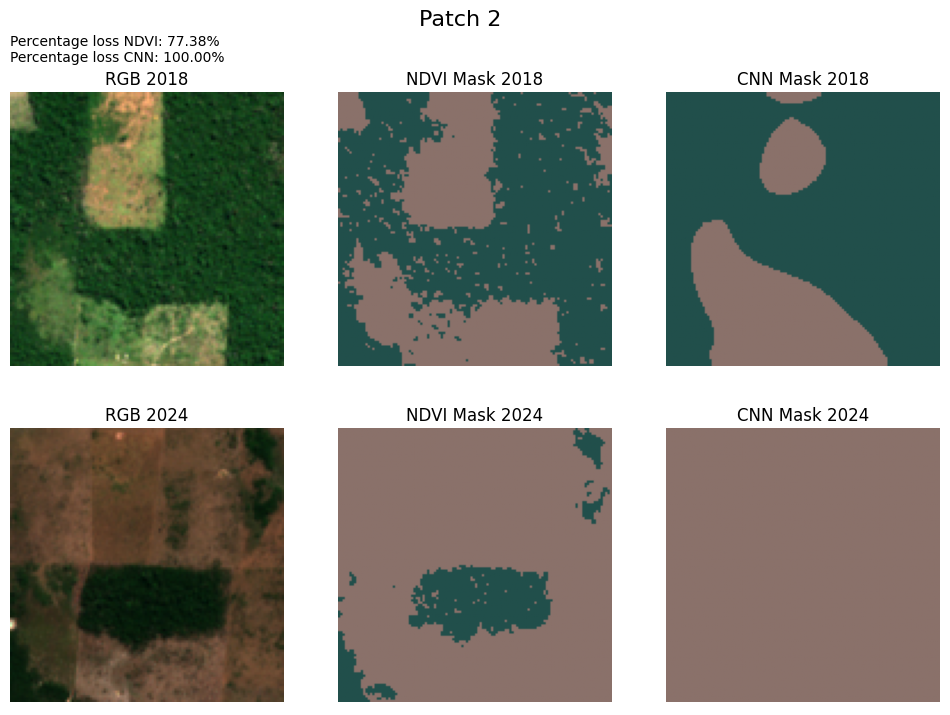

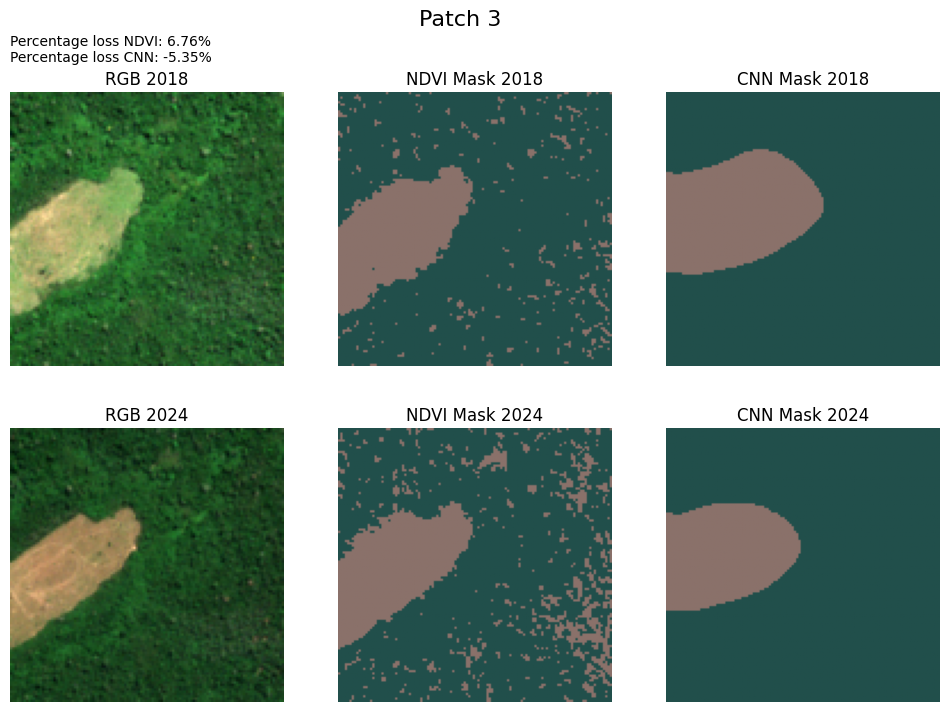

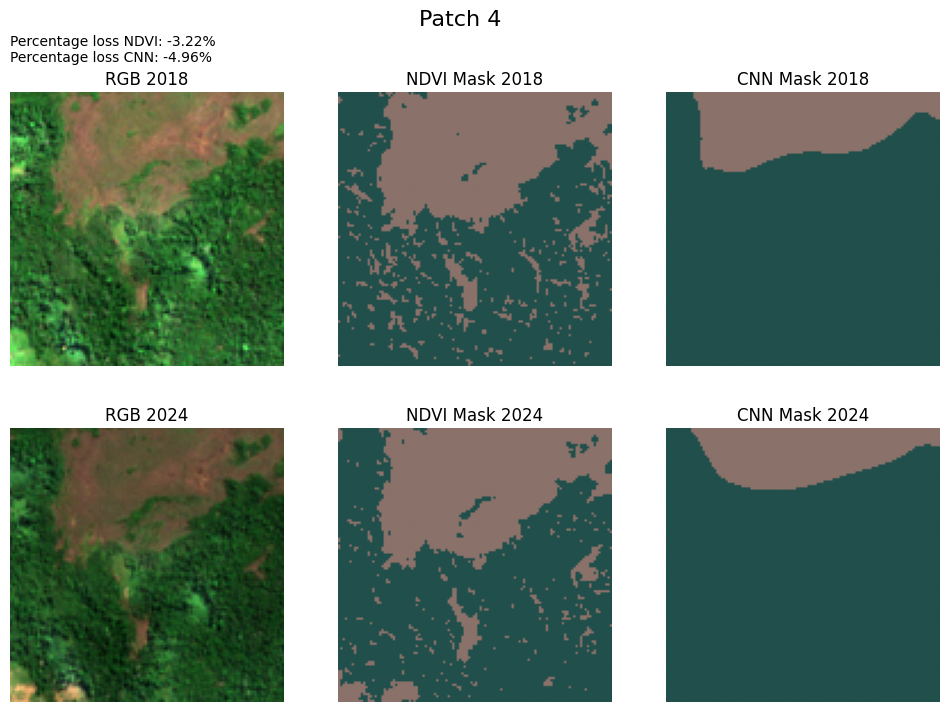

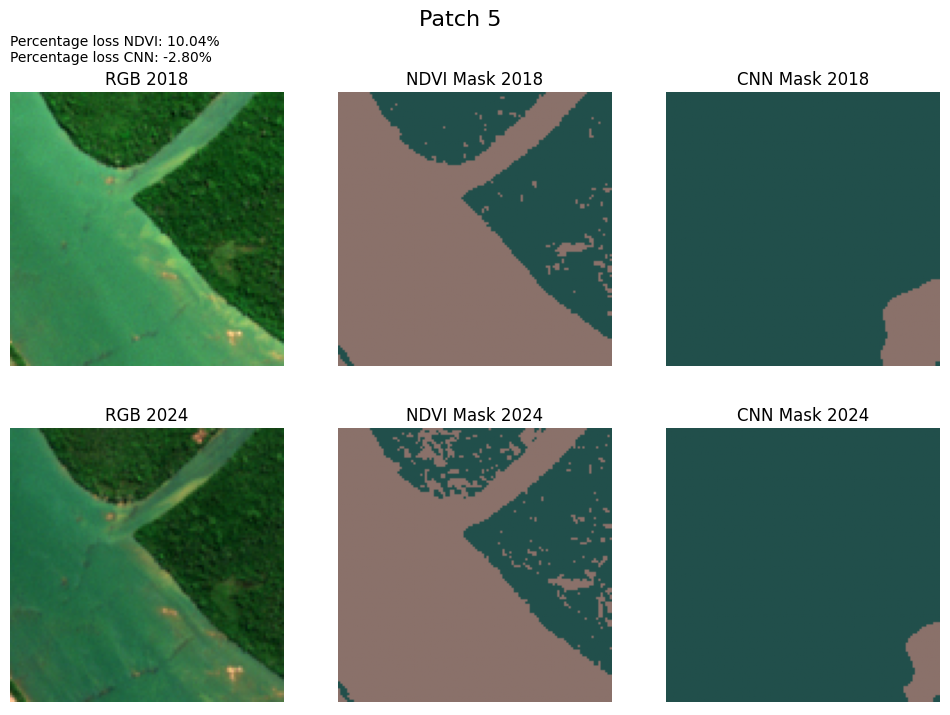

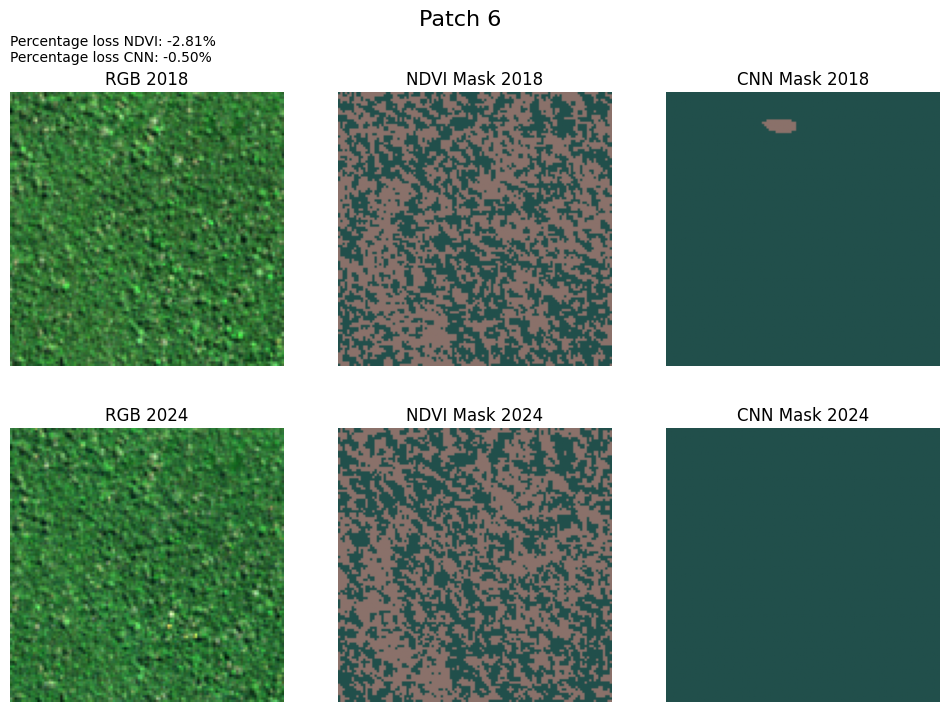

In [10]:
from matplotlib.colors import ListedColormap

for i in range(len(representatives_patches_2018)):
    patch_2018 = representatives_patches_2018[i]
    patch_2024 = representatives_patches_2024[i]
    ndvi_2018 = representatives_ndvi_2018[i]
    ndvi_2024 = representatives_ndvi_2024[i]
    cnn_2018 = representatives_cnn_2018[i]
    cnn_2024 = representatives_cnn_2024[i]

    forest_pixels_2018_ndvi = count_forest_pixels([ndvi_2018])
    forest_pixels_2024_ndvi = count_forest_pixels([ndvi_2024])
    percentage_loss_ndvi = 100 * (forest_pixels_2018_ndvi - forest_pixels_2024_ndvi) / (forest_pixels_2018_ndvi + 1e-6)

    forest_pixels_2018_cnn = count_forest_pixels([cnn_2018])
    forest_pixels_2024_cnn = count_forest_pixels([cnn_2024])
    percentage_loss_cnn = 100 * (forest_pixels_2018_cnn - forest_pixels_2024_cnn) / (forest_pixels_2018_cnn + 1e-6)
    
    bands = [2,1,0] # RGB (B04, B03, B02)
    patch_2018 = patch_2018[:, :, bands]
    patch_2018 = (patch_2018 - patch_2018.min()) / (patch_2018.max() - patch_2018.min() + 1e-6)
    patch_2024 = patch_2024[:, :, bands]
    patch_2024 = (patch_2024 - patch_2024.min()) / (patch_2024.max() - patch_2024.min() + 1e-6)

    cmap = ListedColormap(["#8A716A", "#214F4B"]) # brown (non-forest) and green (forest)     
    plt.figure(figsize=(12, 8))

    plt.suptitle(f"Patch {i+1}", fontsize=16)
    plt.title(f"Percentage loss NDVI: {percentage_loss_ndvi:.2f}%\nPercentage loss CNN: {percentage_loss_cnn:.2f}%", loc="left",  pad=20, fontsize=10)
    plt.axis("off")
    
    plt.subplot(2, 3, 1)
    plt.title("RGB 2018")
    plt.imshow(patch_2018)
    plt.axis("off")
    
    plt.subplot(2, 3, 2)
    plt.title("NDVI Mask 2018")
    plt.imshow(ndvi_2018, cmap=cmap, vmin=0, vmax=1)
    plt.axis("off")

    plt.subplot(2, 3, 3)
    plt.title("CNN Mask 2018")
    plt.imshow(cnn_2018, cmap=cmap, vmin=0, vmax=1)
    plt.axis("off")

    plt.subplot(2, 3, 4)
    plt.title("RGB 2024")
    plt.imshow(patch_2024)
    plt.axis("off")

    plt.subplot(2, 3, 5)
    plt.title("NDVI Mask 2024")
    plt.imshow(ndvi_2024, cmap=cmap, vmin=0, vmax=1)
    plt.axis("off")
    
    plt.subplot(2, 3, 6)
    plt.title("CNN Mask 2024")
    plt.imshow(cnn_2024, cmap=cmap, vmin=0, vmax=1)
    plt.axis("off")
    
    plt.show()

## 3.4 Method Comparison and Interpretation

Write a detailed qualitative evaluation (~500 words) discussing:

- Describe your plots.
- Which method performed more robustly across varying conditions. Why?
- Sensitivity to atmospheric noise, and classification errors.
- Advantages and limitations of both approaches.
- Possible improvements of both methods.
- Which method you would recommend for systematic deforestation assessment.
- Further remarks/ observations.



**TODO:** Describe the results.

**Plot Description**

The first two patches are examples of high loss. For the first patch, NDVI covers the forest area in both years fairly well. However, the forest areas contain some non-forest spots, which are allegedly caused by atmospheric noise. The CNN, on the other hand, roughly locates the forest but does not recognize its shape as much as the NDVI method. The classification performance of both methods on patch 2 looks similar to that on patch 1. Additionally, the CNN often does not recognize forested regions at all, as shown in the CNN mask for patch 2 in 2024. Patches 3 and 4 indicate regions with minimal loss. The results of both techniques look decent.

In contrast, the outcomes of NDVI and CNN differ a lot as they both handle water differently. NDVI can easily differentiate vegetation from water, whereas the CNN cannot yet distinguish them well. For patch 6, both methods also show discrepancies. You can see that atmospheric noise has a huge effect on NDVI such that forested regions are not clearly visible in the NDVI mask. Compared to that, the CNN indeed identifies all pixels as forest.

**Which method performed more robustly across varying conditions. Why?**

In this task, NDVI performed better than the CNN overall. Although NDVI is prone to noise and sometimes classifies pixels with some vegetation (e.g., meadows) as forest, the shapes of forest and non-forest areas in the NDVI masks are more accurate than those in the CNN's masks. Additionally, it is often the case that the CNN identifies randomly shaped areas of forest as non-forest and vice versa.

**Sensitivity to atmospheric noise, and classification errors**

The CNN did not seem to be sensitive to atmospheric noise compared to the NDVI method, whose predictions often include scattering from non-forest pixels. For both methods, the respective threshold must be set correctly to avoid classification errors. If it is set too low, the predictions might have a lot of false positives (non-forest marked as forest). If it is set too high, there might be more false negatives (forest marked as non-forest).

**Advantages and limitations of both approaches**

Since NDVI only uses the near-infrared and red bands, less data is required. It is also computationally fast, easy to implement and its outcome is explainable, as we know that green vegetation has the property of high reflectance in the near-infrared band and low reflectance in the red band. However, one limitation is its sensitivity to noise. Therefore, we have to find a trade-off between overclassification and noise sensitivity by choosing the right threshold. Moreover, NDVI works only on green vegetation. If we apply this method to a leafless forest during winter, the method won't be able to identify the forest.

The CNN can overcome the limitations of the NDVI method when properly trained and tuned. While NDVI classifies each pixel independently, a CNN considers the spatial neighborhood of a pixel. Furthermore, it uses more bands than the near-infrared and red bands to distinguish vegetation from other surface types. Therefore, the CCN is more flexible and can be applied to different biomes and seasons. If trained well, it can also handle noise and artifacts more robustly. Nevertheless, there are several practical challenges when using a CNN. Firstly, training a CNN requires large and diverse training data, which is often limited or not available. Furthermore, the learning process is expensive since it consists of data preprocessing, training, evaluation and fine-tuning. At the same time, you must also avoid overfitting and underfitting. Additionally, the CNN's decisions might also not be explainable.

**Which method for systematic deforestation assessment**

Right now, NDVI appears to be a better option for estimating forest loss. If the CNN is improved further, it could outperform NDVI.